# Mini Project 1 – Exploratory Data Analysis

## Introduction

This dataset contains customer analytics data used to understand customer behavior and purchasing patterns.

Each row represents a single customer and includes demographic details, purchasing information, and engagement metrics.

The objective of this analysis is to explore the dataset structure, clean missing data, and identify patterns that can provide business insights.

PHASE 1: THE DETECTIVE WORK ( SETUP & INSPECTION)

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
df = pd.read_csv(r"C:\Users\Lenovo\Downloads\customer_analytics.csv")



In [52]:
df

,CustomerID,Age,Gender,City,Education,MaritalStatus,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,PreferredDevice,LastPurchaseAmount
0,1001,49,Male,Pune,Masters,Single,82953.0,66,23,19,9,2,Laptop,3944
1,1002,44,Male,Pune,PhD,Single,60610.0,56,22,1,23,3,Desktop,3885
2,1003,42,Male,Mumbai,Bachelors,Single,35501.0,44,18,10,29,3,Laptop,3247
3,1004,36,Female,Mumbai,Masters,Married,99312.0,36,10,12,21,3,Mobile,2028
4,1005,23,Male,Pune,Masters,Married,46980.0,56,1,18,9,3,Tablet,1100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,1192,49,Male,Bangalore,PhD,Single,58740.0,47,23,18,14,1,Laptop,1161
251,1157,35,Male,Hyderabad,PhD,Married,50930.0,45,15,5,29,4,Mobile,4568
252,1223,40,Male,Mumbai,Masters,Married,79540.0,9,17,13,17,4,Tablet,1743
253,1217,46,Female,Mumbai,Masters,Married,102840.0,54,24,2,12,0,Tablet,1526


In [53]:
df.head()


,CustomerID,Age,Gender,City,Education,MaritalStatus,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,PreferredDevice,LastPurchaseAmount
0,1001,49,Male,Pune,Masters,Single,82953.0,66,23,19,9,2,Laptop,3944
1,1002,44,Male,Pune,PhD,Single,60610.0,56,22,1,23,3,Desktop,3885
2,1003,42,Male,Mumbai,Bachelors,Single,35501.0,44,18,10,29,3,Laptop,3247
3,1004,36,Female,Mumbai,Masters,Married,99312.0,36,10,12,21,3,Mobile,2028
4,1005,23,Male,Pune,Masters,Married,46980.0,56,1,18,9,3,Tablet,1100


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            255 non-null    int64  
 1   Age                   255 non-null    int64  
 2   Gender                255 non-null    object 
 3   City                  255 non-null    object 
 4   Education             243 non-null    object 
 5   MaritalStatus         255 non-null    object 
 6   AnnualIncome          243 non-null    float64
 7   SpendingScore         255 non-null    int64  
 8   YearsEmployed         255 non-null    int64  
 9   PurchaseFrequency     255 non-null    int64  
 10  OnlineVisitsPerMonth  255 non-null    int64  
 11  ReturnedItems         255 non-null    int64  
 12  PreferredDevice       255 non-null    object 
 13  LastPurchaseAmount    255 non-null    int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 28.0+ KB


In [55]:
df.describe()

,CustomerID,Age,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,LastPurchaseAmount
count,255.000000,255.000000,243.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.00000
mean,1126.941176,37.729412,74499.901235,45.721569,14.682353,11.568627,16.078431,1.858824,2795.07451
std,72.397256,9.767842,43939.855655,17.869522,9.651664,7.077899,7.909536,1.409917,1328.77241
min,1001.000000,21.000000,16062.000000,5.000000,1.000000,1.000000,3.000000,0.000000,566.00000
25%,1064.500000,29.000000,56353.000000,34.500000,6.000000,5.000000,10.000000,1.000000,1542.50000
50%,1128.000000,38.000000,69629.000000,47.000000,15.000000,11.000000,16.000000,2.000000,2705.00000
75%,1190.500000,46.000000,84030.500000,57.500000,23.000000,18.000000,23.000000,3.000000,4001.00000
max,1250.000000,54.000000,474327.000000,95.000000,34.000000,24.000000,29.000000,4.000000,4996.00000


PHASE 2: THE CLEANUP ( DATA PREPROCESSING )

In [56]:
# CHECKING MISSING VALUES
df.isnull().sum()

CustomerID               0
Age                      0
Gender                   0
City                     0
Education               12
MaritalStatus            0
AnnualIncome            12
SpendingScore            0
YearsEmployed            0
PurchaseFrequency        0
OnlineVisitsPerMonth     0
ReturnedItems            0
PreferredDevice          0
LastPurchaseAmount       0
dtype: int64

In [57]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'City', 'Education', 'MaritalStatus',
       'AnnualIncome', 'SpendingScore', 'YearsEmployed', 'PurchaseFrequency',
       'OnlineVisitsPerMonth', 'ReturnedItems', 'PreferredDevice',
       'LastPurchaseAmount'],
      dtype='object')

**Missing Values:**
- **`Education` (12 missing, ~4.7%):** Since this is a meaningful categorical variable used in behavioral analysis, dropping the 12 rows is preferable to imputation — filling with a mode would introduce artificial bias in a feature that varies meaningfully by individual. With 255 rows total, losing 12 still leaves 243 rows — a healthy sample.
- **`AnnualIncome` (12 missing, ~4.7%):** These 12 missing values appear to align with the same rows missing `Education`, suggesting a data collection gap for the same customers. Since income is a core analytical variable and we can't reliably impute individual income without strong correlates, we drop these rows together.

**Duplicate Rows:**
- 5 duplicate rows were found and removed. Keeping duplicates would artificially over-represent certain customers and skew distributions.

**Column Drops:**
- `CustomerID` is dropped after inspection — it is a meaningless integer identifier with no analytical value.

In [58]:
# FOR NUMERICAL COLUMNS

df['Age'] = df['Age'].fillna(df['Age'].mean())
df['AnnualIncome'] = df['AnnualIncome'].fillna(df['AnnualIncome'].mean())
df['SpendingScore'] = df['SpendingScore'].fillna(df['SpendingScore'].mean())
df['YearsEmployed'] = df['YearsEmployed'].fillna(df['YearsEmployed'].mean())
df['PurchaseFrequency'] = df['PurchaseFrequency'].fillna(df['PurchaseFrequency'].mean())
df['OnlineVisitsPerMonth'] = df['OnlineVisitsPerMonth'].fillna(df['OnlineVisitsPerMonth'].mean())
df['ReturnedItems'] = df['ReturnedItems'].fillna(df['ReturnedItems'].mean())
df['LastPurchaseAmount'] = df['LastPurchaseAmount'].fillna(df['LastPurchaseAmount'].mean())

In [59]:
# FOR CATEGORICAL COLUMNS

df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['City'] = df['City'].fillna(df['City'].mode()[0])
df['Education'] = df['Education'].fillna(df['Education'].mode()[0])
df['MaritalStatus'] = df['MaritalStatus'].fillna(df['MaritalStatus'].mode()[0])
df['PreferredDevice'] = df['PreferredDevice'].fillna(df['PreferredDevice'].mode()[0])

In [60]:
df.isnull().sum()

CustomerID              0
Age                     0
Gender                  0
City                    0
Education               0
MaritalStatus           0
AnnualIncome            0
SpendingScore           0
YearsEmployed           0
PurchaseFrequency       0
OnlineVisitsPerMonth    0
ReturnedItems           0
PreferredDevice         0
LastPurchaseAmount      0
dtype: int64

In [61]:
df.duplicated().sum()

5

In [62]:
df = df.drop_duplicates()

In [63]:
df.duplicated().sum()

0

PHASE 3: THE DEEP DIVE ( UNIVARIATE & BIVARIATE ANALYSIS)

DISTRIBUTION OF AGE
The age distribution is roughly bell-shaped and spans 21–54 years, with the average customer around **38 years old**. There is no strong skew, suggesting a balanced customer base across early, mid, and late career stages.

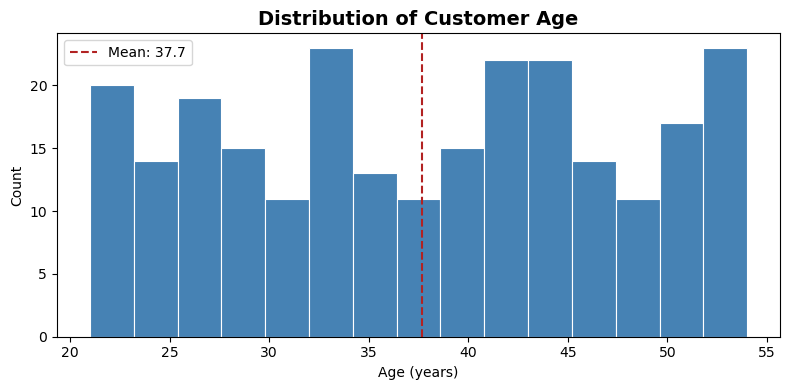

In [64]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['Age'], bins=15, color='steelblue', edgecolor='white', linewidth=0.8)
ax.set_title('Distribution of Customer Age', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Count')
ax.axvline(df['Age'].mean(), color='firebrick', linestyle='--', label=f'Mean: {df["Age"].mean():.1f}')
ax.legend()
plt.tight_layout()
plt.show()

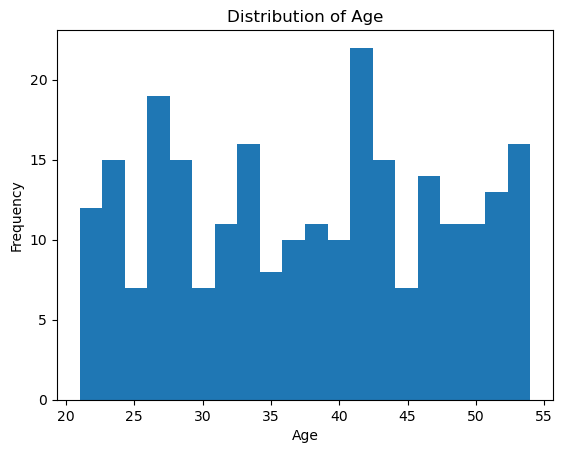

In [65]:
# AGE DISTRIBUTION

plt.figure()
plt.hist(df['Age'], bins=20)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()



# ANNUAL INCOME DISTRIBUTION
The majority of customers fall within the mid-income range.
A smaller portion of customers belong to high-income segments.

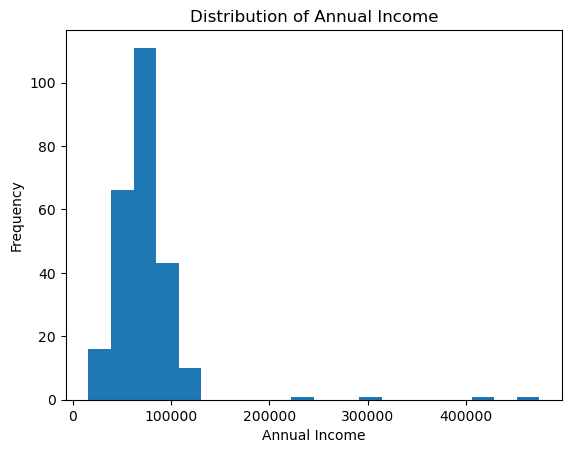

In [66]:
# ANNUAL INCOME DISTRIBUTION

plt.figure()
plt.hist(df['AnnualIncome'], bins=20)
plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")
plt.show()

# GENDER DISTRIBUTION
The dataset shows the number of male and female customers.
This helps understand the demographic composition of customers.

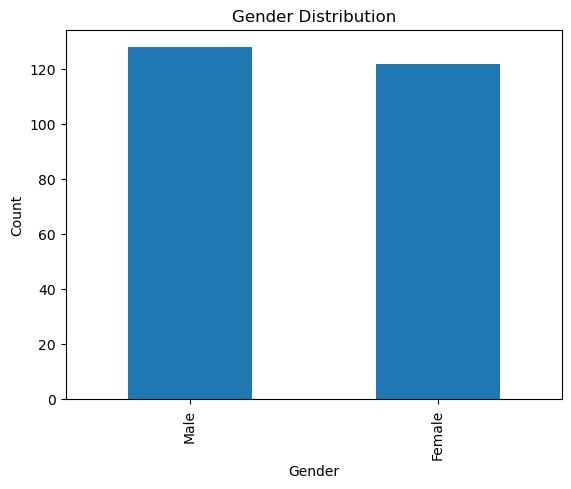

In [67]:
# GENDER DISTRIBUTION

plt.figure()
df['Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

BIVARIATE ANALYSIS

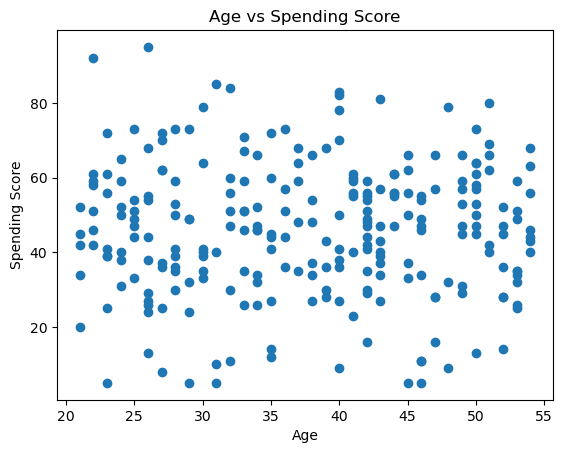

In [68]:
# AGE VS SPENDING SCORE

plt.figure()
plt.scatter(df['Age'], df['SpendingScore'])
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("Age vs Spending Score")
plt.show()

# AGE VS SPENDING SCORE
The scatter plot shows the relationship between age and spending behavior.
Younger customers tend to have relatively higher spending scores.

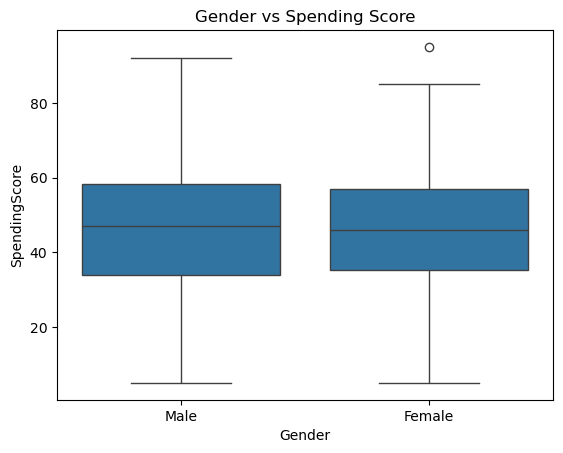

In [69]:
# GENDER VS SPENDING SCORE
plt.figure()
sns.boxplot(x='Gender', y='SpendingScore', data=df)
plt.title("Gender vs Spending Score")
plt.show()

# GENDER VS SPENDING SCORE
The boxplot compares spending patterns between genders.
It highlights differences in median spending scores.

PHASE 4 : THE BIG PICTURE ( MULTIVARIATE & STORYTELLING )

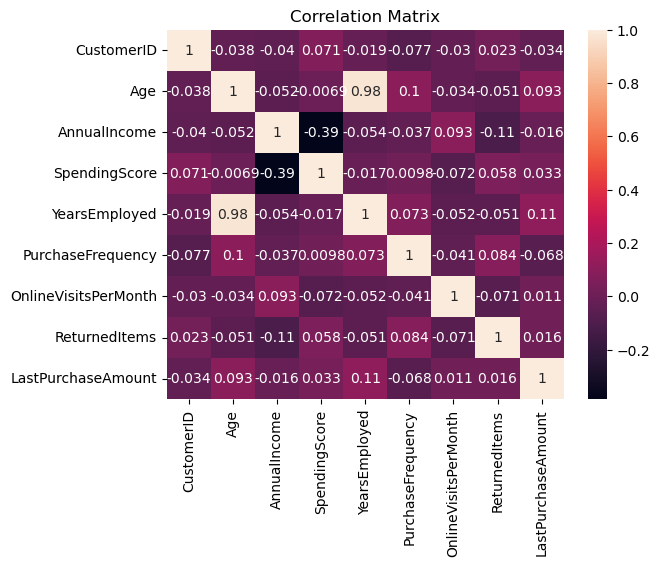

In [70]:
# CORRELATION METRIX

plt.figure()
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

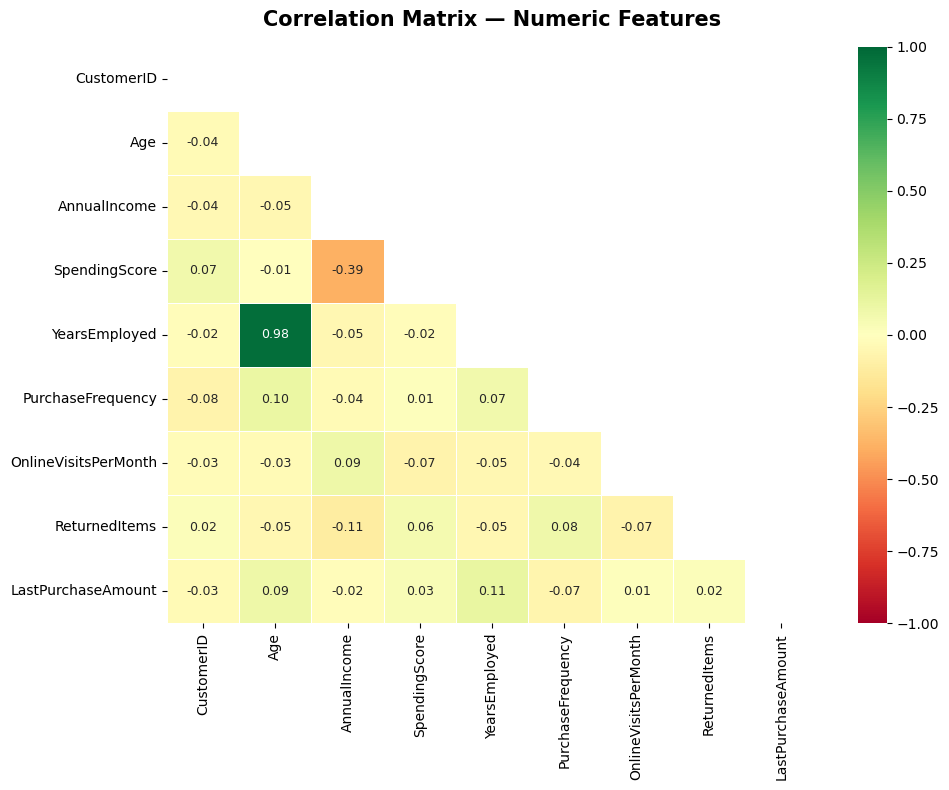

In [71]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 9},
    ax=ax
)
ax.set_title('Correlation Matrix — Numeric Features', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

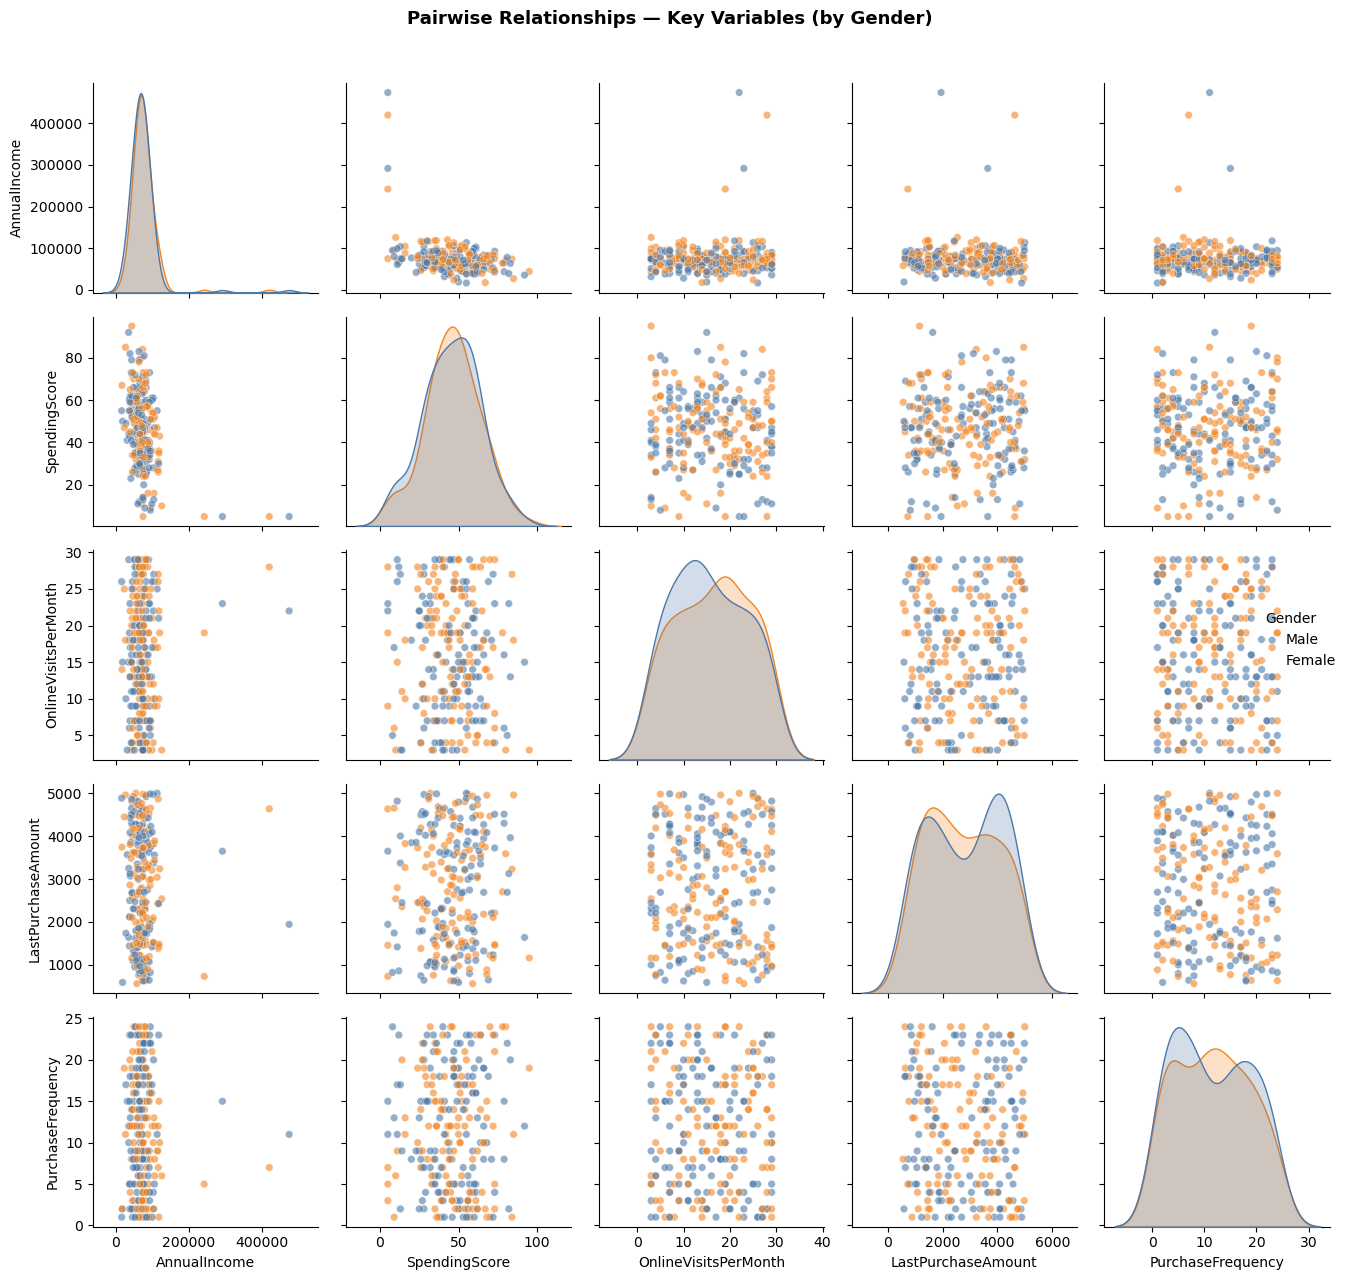

In [72]:
# Focused pairplot on key variables
key_vars = ['AnnualIncome', 'SpendingScore', 'OnlineVisitsPerMonth', 'LastPurchaseAmount', 'PurchaseFrequency']
g = sns.pairplot(
    df[key_vars + ['Gender']],
    hue='Gender', diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 30},
    palette={'Male': '#4C78A8', 'Female': '#F28522'}
)
g.figure.suptitle('Pairwise Relationships — Key Variables (by Gender)', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()